# 06 — PIXELAV cluster simulation (per-sensor detector response)

Notebook 05 turned the shower cascade into a list of **per-sensor charged-track crossings** —
the Stage-B input PIXELAV consumes (entry point, direction cosines, momentum, type). This
notebook closes the loop: it runs **PIXELAV** (M. Swartz's silicon charge-transport Monte
Carlo) on those crossings and shows the resulting **pixel charge clusters** — the detector's
electrical response that a real DECAL readout would record.

Two pieces make this *our* simulation rather than a stock template run:
- **Real entry points.** Stock PIXELAV randomises the sub-pixel impact over the central 3×3
  pixels (its job is to *scan* that dependence into a template). A small patch
  ([`analysis/pixelav/ppixelav2_list_trkpy_real_entry.c`](../analysis/pixelav/ppixelav2_list_trkpy_real_entry.c))
  instead injects each crossing's **real** impact from the deck.
- **The DECAL sensor.** A Stage-A model for our 320 µm-thick, 100 µm-pitch silicon
  ([`analysis/pixelav/make_decal_stagea.py`](../analysis/pixelav/make_decal_stagea.py)): a simple
  uniform depletion field, B = 0, and an FFT-computed Ramo weighting potential.

The full build/run recipe and the reproducible setup are in
[`docs/pixelav_journey_log.md`](../docs/pixelav_journey_log.md) and
[`setup/setup_pixelav.sh`](../setup/setup_pixelav.sh). **Units:** charge in e-h pairs, lengths in
pixels (100 µm) / µm.

In [1]:
import os, numpy as np, matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

TY, TX = 13, 21            # PIXELAV pixel array: 13 rows (y, Lorentz axis), 21 cols (x)
CENTER_ROW, CENTER_COL = 6, 10   # center pixel pix_06_10

def parse_clusters(path):
    """Parse a PIXELAV cluster file -> list of (header, grid). grid is the 13x21 total
    charge (sum of the 20 CR-RC time slices, x10 sampling factor -> e-h pairs)."""
    clusters, cur, hdr = [], None, None
    for line in open(path):
        s = line.strip()
        if s.startswith('<cluster>'):
            if cur is not None: clusters.append((hdr, np.array(cur)))
            cur, hdr = [], None; continue
        if cur is None or s.startswith('<'): continue
        p = s.split()
        if hdr is None and len(p) == 9: hdr = [float(x) for x in p]
        elif len(p) == TX: cur.append([float(x) for x in p])
    if cur is not None: clusters.append((hdr, np.array(cur)))
    out = []
    for hdr, a in clusters:
        if a.size == 0: continue
        nsl = a.shape[0] // TY
        g = a[:nsl*TY].reshape(nsl, TY, TX).sum(0) * 10.0   # x10 sampling -> e-h pairs
        out.append((hdr, g))
    return out

EX = parse_clusters('../models/pixelav_clusters_examples.out')
print(f'{len(EX)} example clusters loaded')

6 example clusters loaded


## 1. Example clusters — what PIXELAV returns

Each panel is one crossing's induced charge on the 21×13 pixel patch (column = x / 21-px axis,
row = y / 13-px axis), summed over the 20 readout time slices. The track always crosses near the
centre pixel; what changes the cluster's **shape** is the track's angle and where within the
pixel it enters. All six below are at the same nominal entry except where noted.

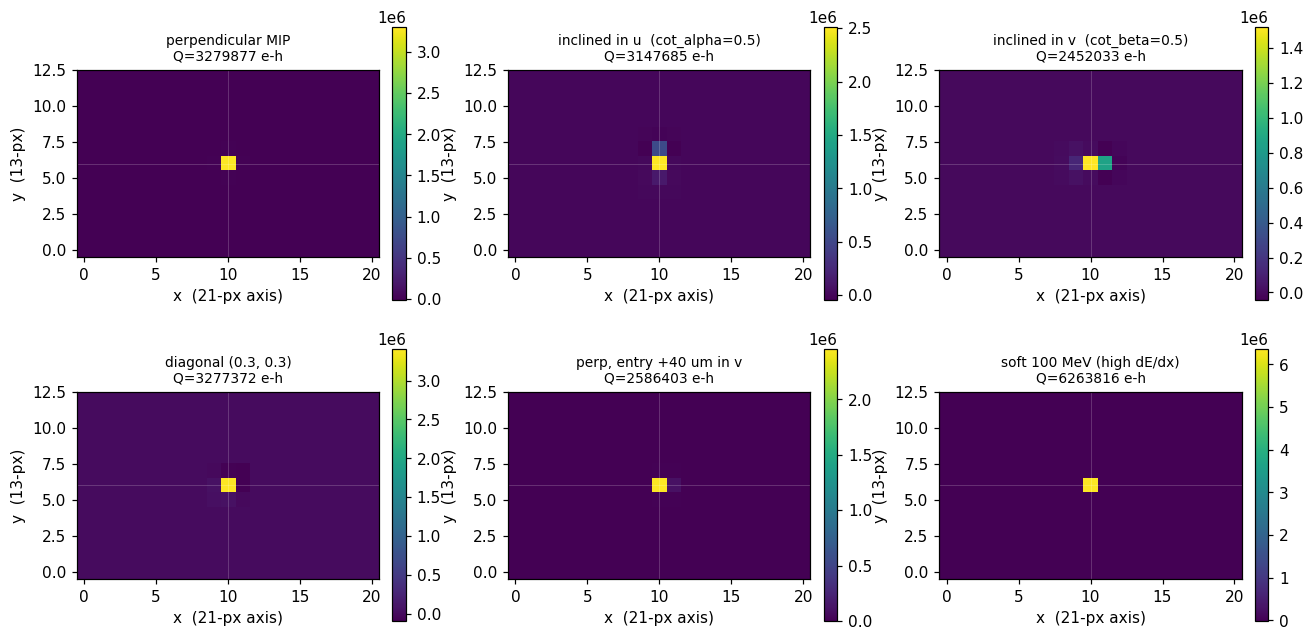

In [2]:
titles = ['perpendicular MIP', 'inclined in u  (cot_alpha=0.5)', 'inclined in v  (cot_beta=0.5)',
          'diagonal (0.3, 0.3)', 'perp, entry +40 um in v', 'soft 100 MeV (high dE/dx)']
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (hdr, g), title in zip(axes.flat, EX, titles):
    im = ax.imshow(g, origin='lower', cmap='viridis', aspect='equal')
    ax.set_title(f'{title}\nQ={g.sum():.0f} e-h', fontsize=9)
    ax.set_xlabel('x  (21-px axis)'); ax.set_ylabel('y  (13-px)')
    ax.axhline(CENTER_ROW, color='w', lw=0.4, alpha=0.3); ax.axvline(CENTER_COL, color='w', lw=0.4, alpha=0.3)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## 2. The cot ↔ axis convention, confirmed by the clusters

PIXELAV's driver swaps the alpha/beta labels relative to the CMS text, so the mapping has to be
read off the source (and checked against the binary): **`cot_alpha` drives the 13-px (y, Lorentz)
axis and `cot_beta` the 21-px (x) axis.** Combined with the DECAL local frame (across-pitch *u*,
cylinder-*z* *v*, depth *w*), the deck writes `cot_alpha = p_u/p_w` and `cot_beta = p_v/p_w`.

The two single-axis tracks below confirm it directly: a track inclined in *u* (`cot_alpha`)
elongates the cluster **vertically** (along the 13-px y axis); a track inclined in *v* (`cot_beta`)
elongates it **horizontally** (along the 21-px x axis).

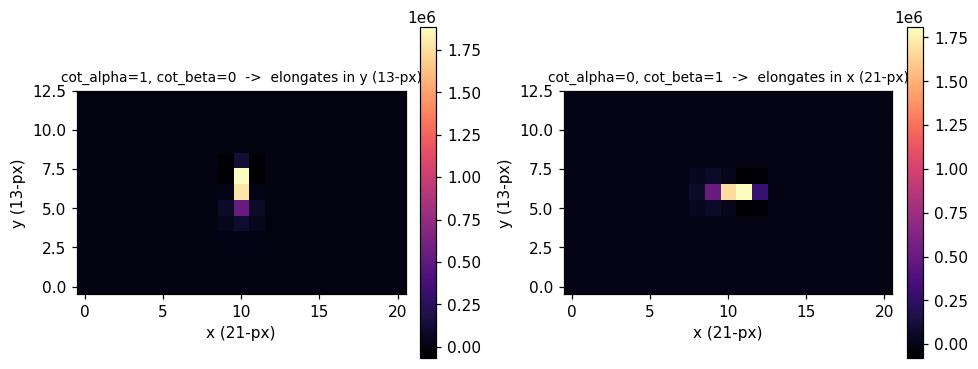

In [3]:
AX = parse_clusters('../models/pixelav_clusters_axis.out')
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
lab = ['cot_alpha=1, cot_beta=0  ->  elongates in y (13-px)',
       'cot_alpha=0, cot_beta=1  ->  elongates in x (21-px)']
for ax, (hdr, g), t in zip(axes, AX, lab):
    im = ax.imshow(g, origin='lower', cmap='magma', aspect='equal')
    ax.set_title(t, fontsize=9); ax.set_xlabel('x (21-px)'); ax.set_ylabel('y (13-px)')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## 3. The full event — every crossing's cluster

Running the whole 50 GeV-photon event (its 2,188 charged-track sensor crossings) through the
DECAL sensor gives one cluster per crossing. The collected charge peaks at the **MIP value for
320 µm of silicon (~25 k e-h)**; the spread reflects the Landau/Bichsel fluctuations and the
range of track angles and momenta in the shower.

*(A fraction of the highest-momentum crossings exceed PIXELAV's internal e-h storage cap and are
skipped — see the journey log; the soft-track bulk that dominates the shower is retained.)*

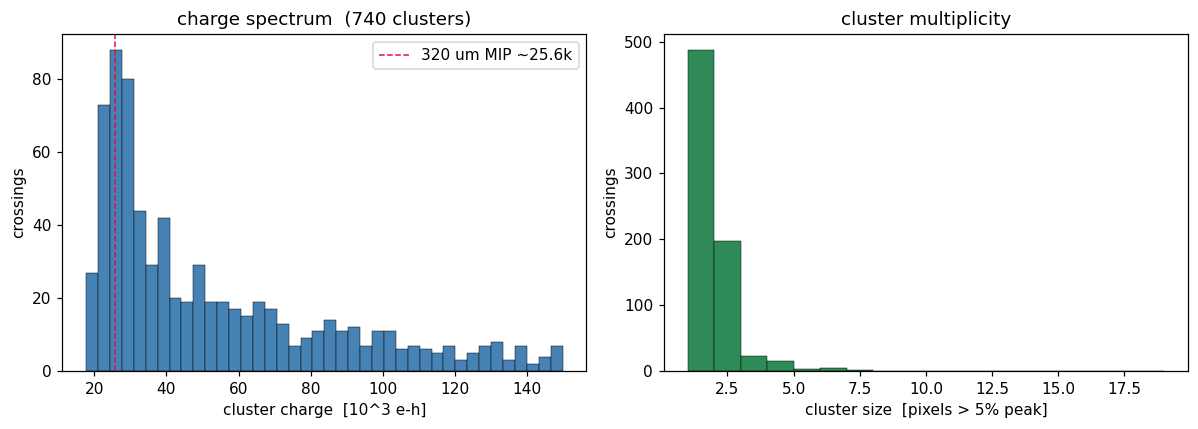

740 clusters; median charge 39594 e-h; median size 1 px


In [4]:
full_path = '../models/pixelav_clusters_full.out'
if os.path.exists(full_path):
    FULL = parse_clusters(full_path)
    neh = np.array([h[6] for h, g in FULL])
    sizes = np.array([(g > 0.05*g.max()).sum() for h, g in FULL])
    fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
    a0.hist(neh/1000, bins=40, color='steelblue', edgecolor='k', lw=0.3)
    a0.axvline(25.6, color='crimson', ls='--', lw=1, label='320 um MIP ~25.6k')
    a0.set_xlabel('cluster charge  [10^3 e-h]'); a0.set_ylabel('crossings'); a0.legend(); a0.set_title(f'charge spectrum  ({len(FULL)} clusters)')
    a1.hist(sizes, bins=range(1, 20), color='seagreen', edgecolor='k', lw=0.3)
    a1.set_xlabel('cluster size  [pixels > 5% peak]'); a1.set_ylabel('crossings'); a1.set_title('cluster multiplicity')
    plt.tight_layout(); plt.show()
    print(f'{len(FULL)} clusters; median charge {np.median(neh):.0f} e-h; median size {np.median(sizes):.0f} px')
else:
    print('full-event cluster file not found; run setup/setup_pixelav.sh + the full deck (see journey log).')

## 4. What is ours, what is simple, and what is next

**Ours (from the simulation):** every cluster's track kinematics — direction, momentum, type, and
the **real sub-pixel entry point** — come from the DECAL Geant4 cascade via notebook 05's deck.
The sensor is **our geometry** (320 µm thick, 100 µm square pixels).

**Simple (by design):** the Stage-A field model is a uniform depletion field with B = 0 and an
analytic Ramo weighting potential — a clean, well-defined stand-in for a full TCAD field map.

**Known limitations** (tracked in the journey log): PIXELAV treats every track as a pion for
dE/dx (e±/µ are a mass-rescaled approximation); the per-crossing momentum is the MCParticle
production momentum (EDM4hep carries no per-step momentum); and the highest-charge crossings hit
PIXELAV's e-h storage cap. Raising fidelity means a TCAD field map (`TCADtoPixelAV`), per-step
momentum, and a larger storage cap.

**Reproduce everything** (on EAF): `bash setup/setup_pixelav.sh`, then run the deck
`models/pixelav_segments_gamma50_1evt.pixelav.txt` through `ppixelav2_list_trkpy_real_entry` in
the generated `decal_run/` directory.